In [42]:
%matplotlib widget

import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".8"

import abtem
import ase
from ase.cluster import Octahedron, Decahedron
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np

from pathlib import Path
import sys
# add parent folder (and common src folder) to sys.path so imports can be resolved
parent = Path.cwd().parent
candidates = [parent, parent / "src"]
for p in candidates:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))


from jax_multislice import (
    get_abtem_transmit, 
    Propagator as convolve2d, 
    energy2wavelength, 
    fresnel_propagation_kernel, 
    angular_spectrum_propagation_kernel, 
    electron_refractive_index,
    wpm_step_adaptive,
    wpm_step,
    )

abtem.config.set({"device": "cpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)

(<Figure size 1200x400 with 2 Axes>,
 <Axes: title={'center': 'Side view'}, xlabel='x [Å]', ylabel='z [Å]'>)

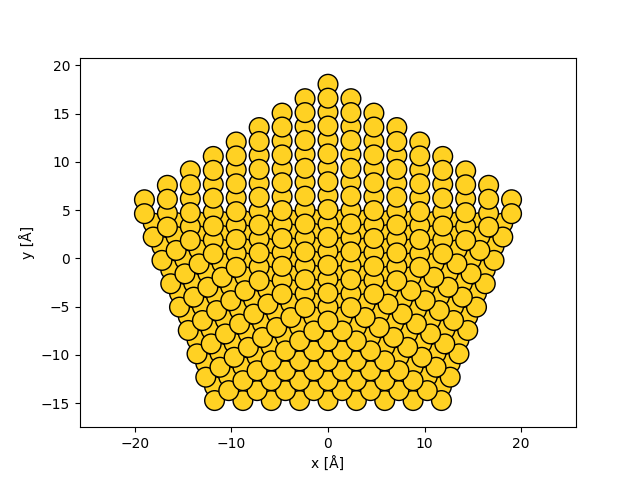

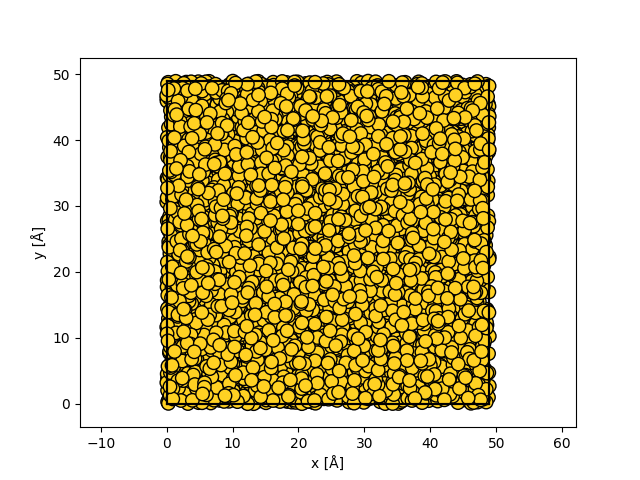

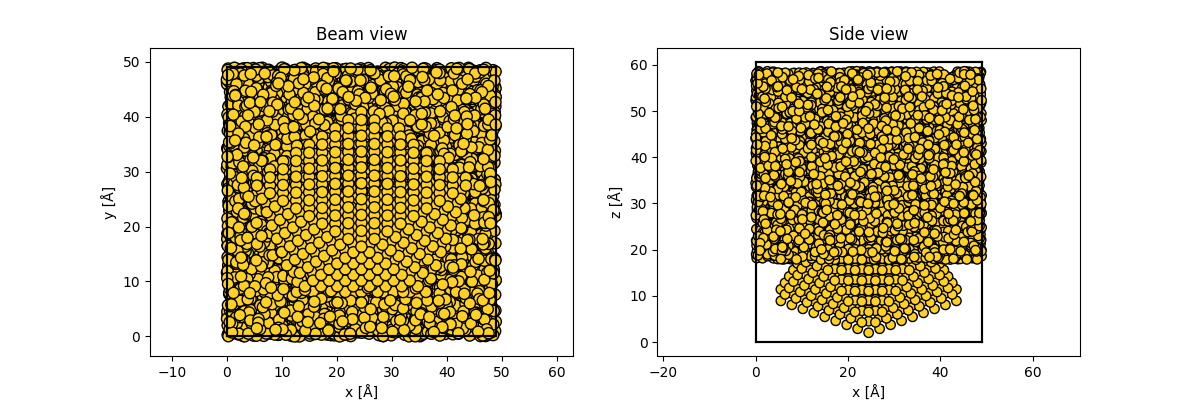

In [43]:
cluster = Decahedron("Au", 9, 2, 0)
cluster.rotate("x", -30)
abtem.show_atoms(cluster, plane="xy")

substrate = ase.build.bulk("Au", cubic=True)

# repeat diamond structure
substrate *= (12, 12, 10)

# displace atoms with a standard deviation of 50 % of the bond length
bondlength = 1.54  # Bond length
substrate.positions[:] += np.random.randn(len(substrate), 3) * 0.5 * bondlength

# wrap the atoms displaced outside the cell back into the cell
substrate.wrap()

abtem.show_atoms(substrate, plane="xy", merge=0.5)

translated_cluster = cluster.copy()

translated_cluster.cell = substrate.cell
translated_cluster.center()
translated_cluster.translate((0, 0, -25))

atoms = substrate + translated_cluster

atoms.center(axis=2, vacuum=2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
abtem.show_atoms(atoms, plane="xy", ax=ax1, title="Beam view")
abtem.show_atoms(atoms, plane="xz", ax=ax2, title="Side view")

In [44]:
slice_thickness = 2.0  # in Angstrom
potential = abtem.Potential(
    atoms,
    gpts=256,
    slice_thickness=slice_thickness,
)
print(potential.shape)

(31, 256, 256)


In [45]:
energy = 200e3
transmit = get_abtem_transmit(potential, energy)

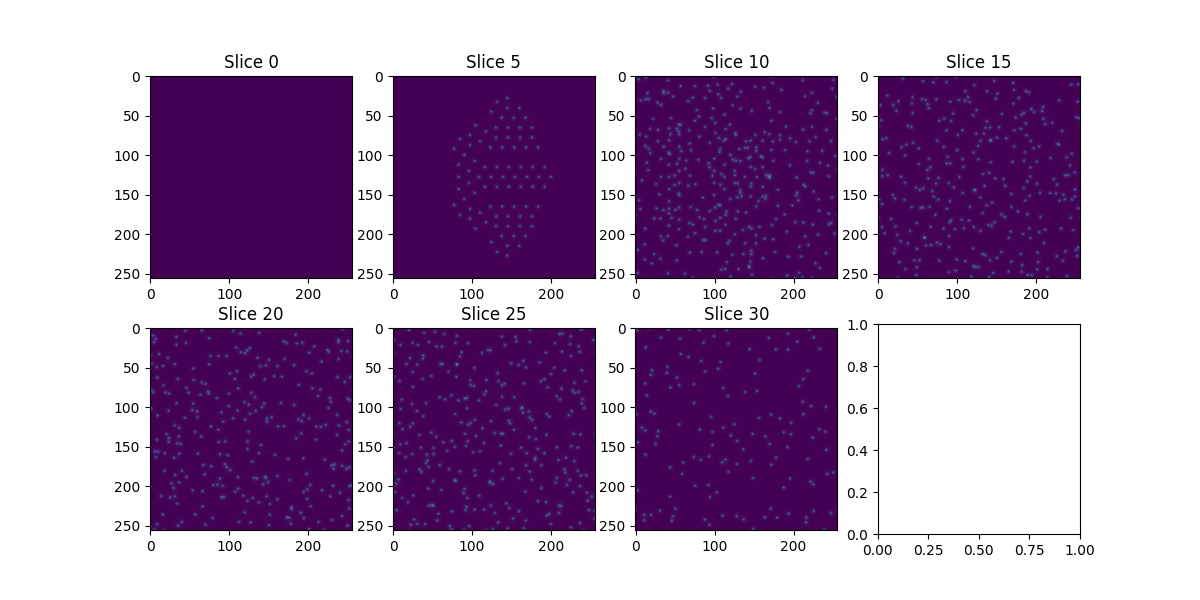

In [46]:
potential_array = potential.build(lazy=False).array
subset = potential_array[::5]

rows = int(np.floor(np.sqrt(len(subset))))
cols = int(np.ceil(np.sqrt(len(subset))))
if rows * cols < len(subset):
    cols += 1
fig, ax = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
vmin = potential_array.min()
vmax = potential_array.max()
for i, (p, s_ax) in enumerate(zip(subset, ax.ravel())):
    s_ax.imshow(p, vmin=vmin, vmax=vmax)
    s_ax.set_title(f"Slice {i * 5}")

In [47]:
wavelength = energy2wavelength(energy)
semiangle_cutoff = 40
defocus = 60
astigmatism = 0.,
astigmatism_angle = 0.,

probe = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    defocus=defocus,
)
probe.grid.match(potential)
probe_array = probe.build(lazy=False).array

Text(0.5, 1.0, 'Probe abtem (angle)')

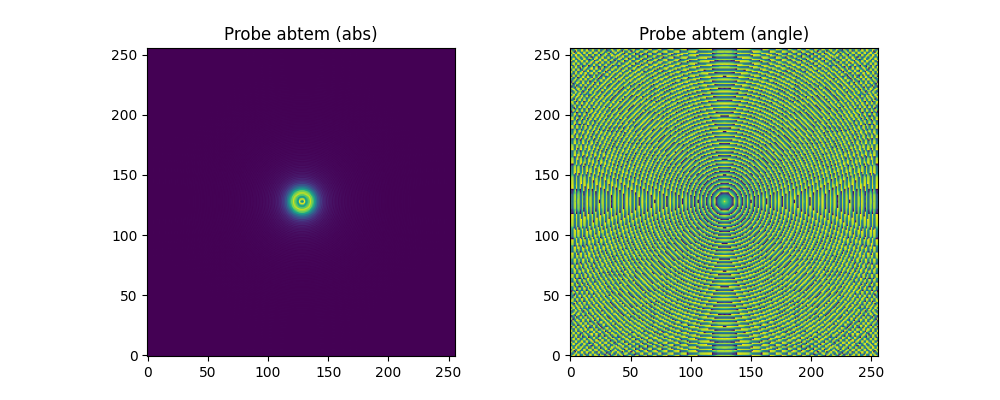

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(np.abs(probe.build(lazy=False).array), origin='lower')
ax1.set_title('Probe abtem (abs)')
ax2.imshow(np.angle(probe.build(lazy=False).array), origin='lower')
ax2.set_title('Probe abtem (angle)')

In [49]:
from tqdm import trange

def simulate_pattern_fresnel_as(potential, probe, prop_kernel, dz):
    wavefront = probe
    wavefronts = []

    for i in range(potential.shape[0]):
        n = electron_refractive_index(potential[i], energy)
        phase_shift = jnp.exp(1j * 2 * jnp.pi * (n - 1) * dz/ wavelength)
        wavefront = wavefront * phase_shift
        wavefront = convolve2d(wavefront, prop_kernel)
        wavefronts.append(wavefront)
    
    exit_wave = wavefront
    
    detector_wavefront = jnp.fft.fftshift(
        jnp.fft.fft2(wavefront)
    )
    diffraction_pattern = (
        jnp.square(detector_wavefront.real)
        + jnp.square(detector_wavefront.imag)
    )
    return exit_wave, diffraction_pattern, jnp.stack(wavefronts)

simulate_pattern_fresnel_as_jit = jax.jit(simulate_pattern_fresnel_as)

simulate_pattern_fresnel_as_jit = jax.jit(simulate_pattern_fresnel_as)

def simulate_pattern_wpm_step(potential, probe, dz, energy, ps):
    wavefront = probe
    wavefronts = []
    for i in trange(potential.shape[0], desc="WPM slices"):
        n = electron_refractive_index(potential[i], energy)
        wavefront = wpm_step(wavefront, n, dz, energy, ps)
        wavefronts.append(wavefront)
    
    exit_wave = wavefront
    
    detector_wavefront = jnp.fft.fftshift(
        jnp.fft.fft2(wavefront)
    )
    diffraction_pattern = (
        jnp.square(detector_wavefront.real)
        + jnp.square(detector_wavefront.imag)
    )
    return exit_wave, diffraction_pattern, jnp.stack(wavefronts)


def simulate_pattern_wpm_step_adaptive(potential, probe, dz, energy, ps):
    wavefront = probe
    wavefronts = []
    for i in trange(potential.shape[0], desc="WPM slices"):
        n = electron_refractive_index(potential[i], energy)
        wavefront, _, _, _ = wpm_step_adaptive(wavefront, n, dz, energy, ps, n_bins=256)
        wavefronts.append(wavefront)
    
    exit_wave = wavefront
    
    detector_wavefront = jnp.fft.fftshift(
        jnp.fft.fft2(wavefront)
    )
    diffraction_pattern = (
        jnp.square(detector_wavefront.real)
        + jnp.square(detector_wavefront.imag)
    )
    return exit_wave, diffraction_pattern, jnp.stack(wavefronts)

simulate_pattern_wpm_step_jit = jax.jit(simulate_pattern_wpm_step)
simulate_pattern_wpm_step_adaptive_jit = jax.jit(simulate_pattern_wpm_step_adaptive)

In [50]:
# Extract sampling as separate values to ensure proper type handling
sampling_x, sampling_y = probe.grid.sampling[0], probe.grid.sampling[1]

fresnel_propagator = fresnel_propagation_kernel(
    probe.grid.gpts[0],
    probe.grid.gpts[1],
    (sampling_x, sampling_y),  # Pass as tuple explicitly
    z=slice_thickness,
    energy=probe.energy,
)

angular_spectrum_propagator = angular_spectrum_propagation_kernel(
    probe.grid.gpts[0],
    probe.grid.gpts[1],
    (sampling_x, sampling_y),  # Pass as tuple explicitly
    z=slice_thickness,
    energy=probe.energy,
)

exit_wave_fresnel, diffraction_pattern_fresnel, wavefronts_fresnel = simulate_pattern_fresnel_as_jit(potential_array, probe_array, fresnel_propagator, slice_thickness)
exit_wave_as, diffraction_pattern_as, wavefronts_as = simulate_pattern_fresnel_as_jit(potential_array, probe_array, angular_spectrum_propagator, slice_thickness)

In [51]:
#exit_wave_wpm, diffraction_pattern_wpm, wavefronts_wpm = simulate_pattern_wpm_step(potential_array, probe_array, slice_thickness, energy, (sampling_x, sampling_y))
exit_wave_wpm_adaptive, diffraction_pattern_wpm_adaptive, wavefronts_wpm_adaptive = simulate_pattern_wpm_step_adaptive(potential_array, probe_array, slice_thickness, energy, (sampling_x, sampling_y))

exit_wave_wpm, diffraction_pattern_wpm, wavefronts_wpm = exit_wave_wpm_adaptive, diffraction_pattern_wpm_adaptive, wavefronts_wpm_adaptive

WPM slices: 100%|██████████| 31/31 [00:00<00:00, 84.50it/s]


## Slice-by-slice Comparison: Intensity and Phase (Normalized)
The plots below show cross-sections (center row) of the wavefronts for each slice. Intensities are normalized to the same global maximum so differences are directly comparable. Phases are wrapped to [-π, π].

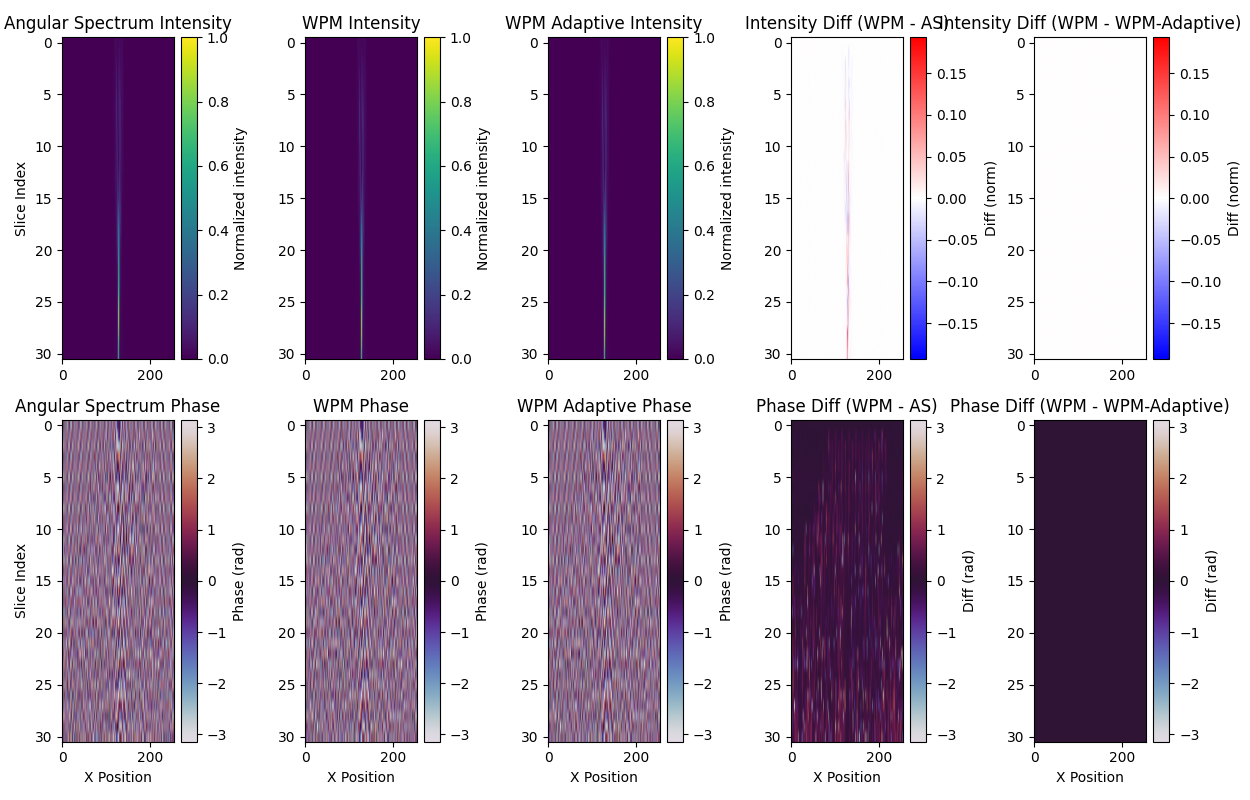

In [52]:
# Expand plot to include AS, WPM, WPM-Adaptive and their differences
cols = 5
fig, ax = plt.subplots(2, cols, figsize=(cols * 2.5, 8))

# Use existing cross-section stacks (shape: [slice, x])
wf_as_cs = np.asarray(wavefronts_as)[:, wavefronts_as.shape[1]//2, :]
wf_wpm_cs = np.asarray(wavefronts_wpm)[:, wavefronts_wpm.shape[1]//2, :]
wf_wpm_ad_cs = np.asarray(wavefronts_wpm_adaptive)[:, wavefronts_wpm_adaptive.shape[1]//2, :]

# Intensities
intensity_as = np.abs(wf_as_cs) ** 2
intensity_wpm = np.abs(wf_wpm_cs) ** 2
intensity_wpm_ad = np.abs(wf_wpm_ad_cs) ** 2

# Global normalization across the three methods
all_max = max(
    intensity_as.max(),
    intensity_wpm.max(),
    intensity_wpm_ad.max(),
)
global_max = all_max if all_max > 0 else 1.0

intensity_as = (intensity_as / global_max).astype(np.float32)
intensity_wpm = (intensity_wpm / global_max).astype(np.float32)
intensity_wpm_ad = (intensity_wpm_ad / global_max).astype(np.float32)

# Intensity differences: WPM - AS, and WPM - WPM_Adaptive
intensity_diff_w_as = intensity_wpm - intensity_as
intensity_diff_w_wad = intensity_wpm - intensity_wpm_ad

# Phases
phase_as = np.angle(wf_as_cs)
phase_wpm = np.angle(wf_wpm_cs)
phase_wpm_ad = np.angle(wf_wpm_ad_cs)

# Phase difference wrapped to [-pi, pi]
def wrap_phase_diff(a, b):
    return (a - b + np.pi) % (2 * np.pi) - np.pi

phase_diff_w_as = wrap_phase_diff(phase_wpm, phase_as)
phase_diff_w_wad = wrap_phase_diff(phase_wpm, phase_wpm_ad)

# Intensity plotting (row 0)
vmax_int = 1.0
im_as = ax[0, 0].imshow(intensity_as, aspect='auto', origin='upper', vmin=0.0, vmax=vmax_int, cmap='viridis')
ax[0, 0].set_title("Angular Spectrum Intensity")
ax[0, 0].set_ylabel("Slice Index")
fig.colorbar(im_as, ax=ax[0, 0], label="Normalized intensity")

im_wpm = ax[0, 1].imshow(intensity_wpm, aspect='auto', origin='upper', vmin=0.0, vmax=vmax_int, cmap='viridis')
ax[0, 1].set_title("WPM Intensity")
fig.colorbar(im_wpm, ax=ax[0, 1], label="Normalized intensity")

im_wpm_ad = ax[0, 2].imshow(intensity_wpm_ad, aspect='auto', origin='upper', vmin=0.0, vmax=vmax_int, cmap='viridis')
ax[0, 2].set_title("WPM Adaptive Intensity")
fig.colorbar(im_wpm_ad, ax=ax[0, 2], label="Normalized intensity")

# Intensity difference colormap limits (symmetric)
vmax_diff = np.max(np.abs(np.stack([intensity_diff_w_as, intensity_diff_w_wad])))
vmax_diff = vmax_diff if vmax_diff > 0 else 1.0

im_diff_w_as = ax[0, 3].imshow(intensity_diff_w_as, aspect='auto', origin='upper', cmap='bwr', vmin=-vmax_diff, vmax=vmax_diff)
ax[0, 3].set_title("Intensity Diff (WPM - AS)")
fig.colorbar(im_diff_w_as, ax=ax[0, 3], label="Diff (norm)")

im_diff_w_wad = ax[0, 4].imshow(intensity_diff_w_wad, aspect='auto', origin='upper', cmap='bwr', vmin=-vmax_diff, vmax=vmax_diff)
ax[0, 4].set_title("Intensity Diff (WPM - WPM-Adaptive)")
fig.colorbar(im_diff_w_wad, ax=ax[0, 4], label="Diff (norm)")

# Phase plotting (row 1)
vmin_phase, vmax_phase = -np.pi, np.pi
p_as = ax[1, 0].imshow(phase_as, aspect='auto', origin='upper', cmap='twilight', vmin=vmin_phase, vmax=vmax_phase)
ax[1, 0].set_title("Angular Spectrum Phase")
ax[1, 0].set_xlabel("X Position")
ax[1, 0].set_ylabel("Slice Index")
fig.colorbar(p_as, ax=ax[1, 0], label="Phase (rad)")

p_wpm = ax[1, 1].imshow(phase_wpm, aspect='auto', origin='upper', cmap='twilight', vmin=vmin_phase, vmax=vmax_phase)
ax[1, 1].set_title("WPM Phase")
ax[1, 1].set_xlabel("X Position")
fig.colorbar(p_wpm, ax=ax[1, 1], label="Phase (rad)")

p_wpm_ad = ax[1, 2].imshow(phase_wpm_ad, aspect='auto', origin='upper', cmap='twilight', vmin=vmin_phase, vmax=vmax_phase)
ax[1, 2].set_title("WPM Adaptive Phase")
ax[1, 2].set_xlabel("X Position")
fig.colorbar(p_wpm_ad, ax=ax[1, 2], label="Phase (rad)")

# Phase differences
im_diff_phase_w_as = ax[1, 3].imshow(phase_diff_w_as, aspect='auto', origin='upper', cmap='twilight', vmin=vmin_phase, vmax=vmax_phase)
ax[1, 3].set_title("Phase Diff (WPM - AS)")
ax[1, 3].set_xlabel("X Position")
fig.colorbar(im_diff_phase_w_as, ax=ax[1, 3], label="Diff (rad)")

im_diff_phase_w_wad = ax[1, 4].imshow(phase_diff_w_wad, aspect='auto', origin='upper', cmap='twilight', vmin=vmin_phase, vmax=vmax_phase)
ax[1, 4].set_title("Phase Diff (WPM - WPM-Adaptive)")
ax[1, 4].set_xlabel("X Position")
fig.colorbar(im_diff_phase_w_wad, ax=ax[1, 4], label="Diff (rad)")

plt.tight_layout()


## Exit Wave & Diffraction Pattern Comparison (Normalized)
Exit waves and diffraction patterns are normalized per-image to the range [0,1] for display. Differences use a symmetric diverging colormap.

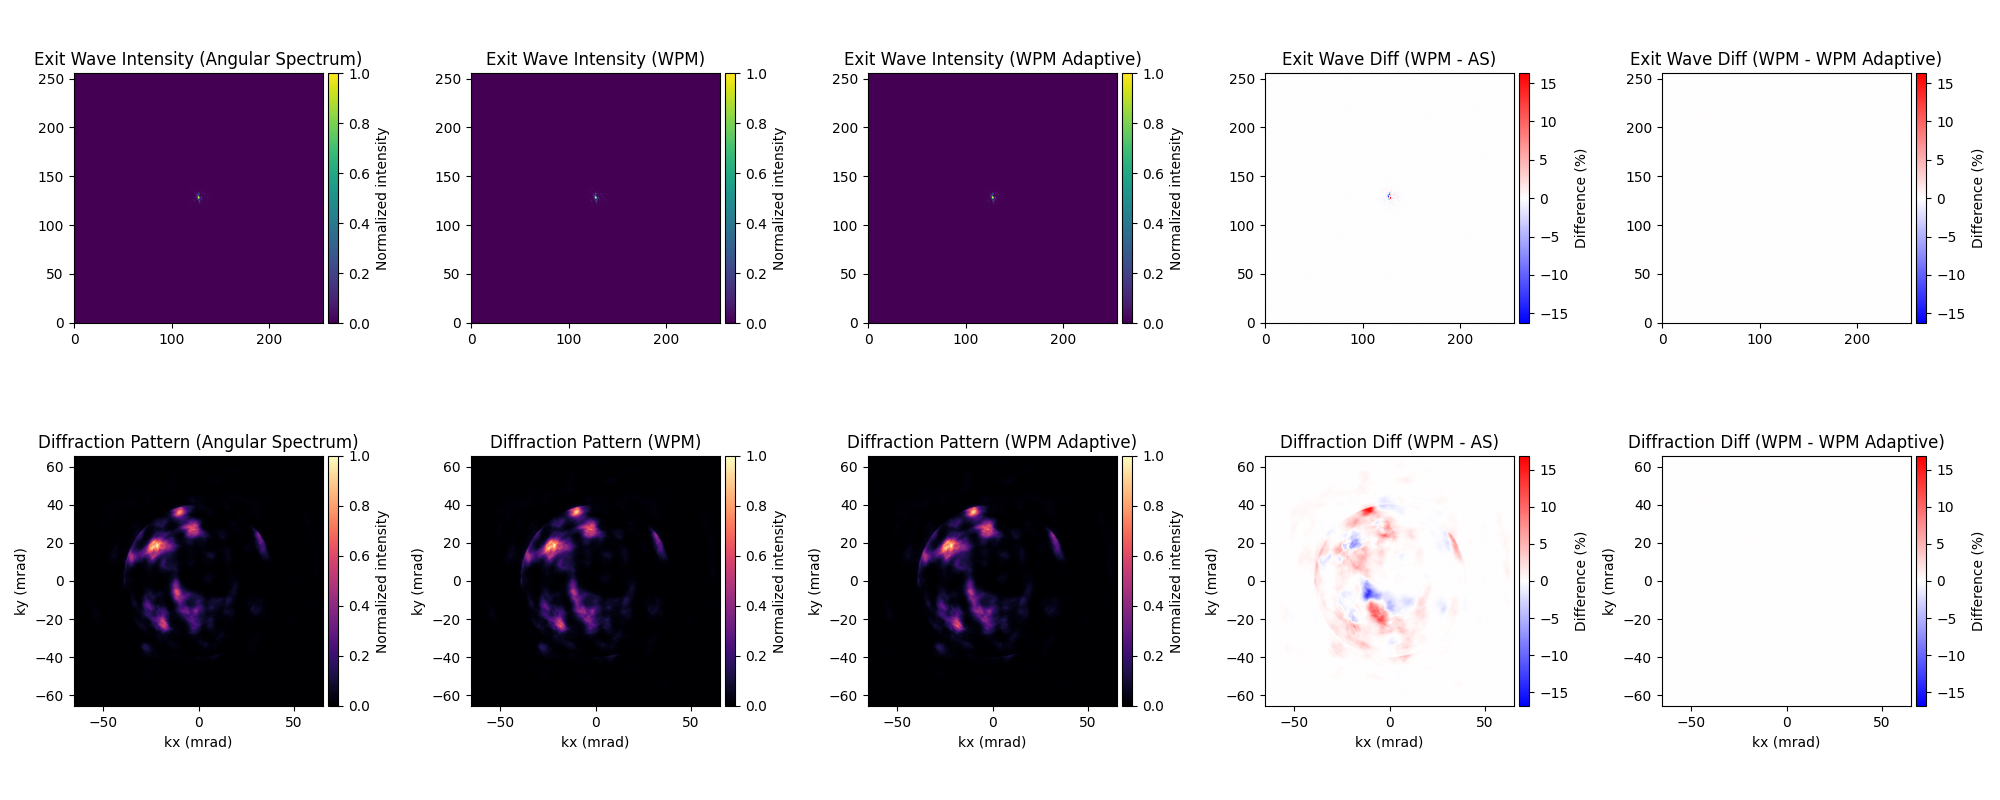

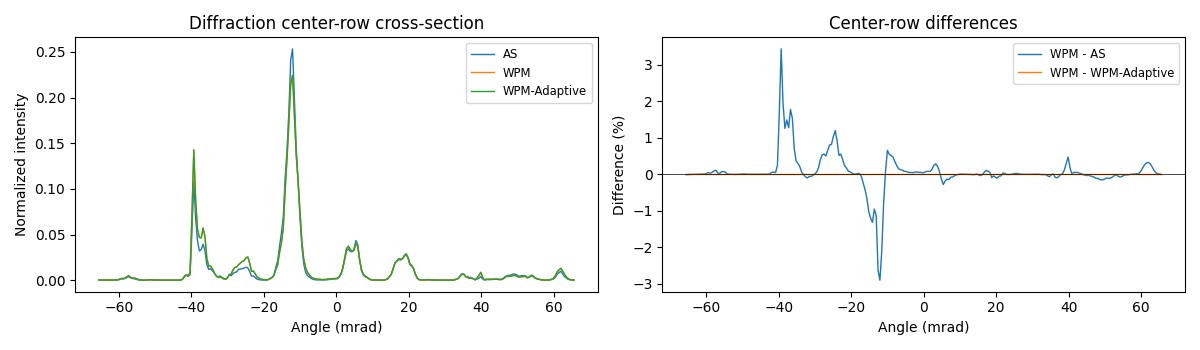

In [53]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# helper to fetch available variable names (tries several common names)
def _get(*names):
    for n in names:
        if n in globals():
            return np.asarray(globals()[n])
    raise NameError(f"None of the names found: {names}")

# get wavefronts (try common name variants)
ew_a = _get("exit_wave_as", "wf_as", "wavefronts_as")
ew_w = _get("exit_wave_wpm", "wf_wpm", "wavefronts_wpm")
ew_ad = _get("exit_wave_wpm_adaptive", "wf_wpm_ad", "wf_wpm_adaptive", "wavefronts_wpm_adaptive")

# get diffraction patterns (try common name variants)
dp_a = _get("diffraction_pattern_as", "dp_a")
dp_w = _get("diffraction_pattern_wpm", "dp_w")
dp_ad = _get("diffraction_pattern_wpm_adaptive", "dp_ad")

# layout: 2 rows x 5 columns
fig, axs = plt.subplots(2, 5, figsize=(20, 8))

# colorbar helper
def add_colorbar(ax, im, size="4%", pad=0.05, **kwargs):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size=size, pad=pad)
    return fig.colorbar(im, cax=cax, **kwargs)

# normalize helper
def norm01(x):
    x = np.asarray(x)
    m = x.max() if x.max() != 0 else 1.0
    return (x / m).astype(np.float32)

# --- Row 1: Exit Wave Intensity (AS, WPM, WPM Adaptive) ---
ew_a_n = norm01(np.abs(ew_a) ** 2)
ew_w_n = norm01(np.abs(ew_w) ** 2)
ew_ad_n = norm01(np.abs(ew_ad) ** 2)

im = axs[0, 0].imshow(ew_a_n, origin='lower', vmin=0.0, vmax=1.0, cmap='viridis')
axs[0, 0].set_title("Exit Wave Intensity (Angular Spectrum)")
add_colorbar(axs[0, 0], im, label="Normalized intensity")

im = axs[0, 1].imshow(ew_w_n, origin='lower', vmin=0.0, vmax=1.0, cmap='viridis')
axs[0, 1].set_title("Exit Wave Intensity (WPM)")
add_colorbar(axs[0, 1], im, label="Normalized intensity")

im = axs[0, 2].imshow(ew_ad_n, origin='lower', vmin=0.0, vmax=1.0, cmap='viridis')
axs[0, 2].set_title("Exit Wave Intensity (WPM Adaptive)")
add_colorbar(axs[0, 2], im, label="Normalized intensity")

# diffs: WPM - AS and WPM - WPM Adaptive (use normalized intensities)
# Calculate percentage difference relative to max intensity
diff_ew_w_as = (ew_w_n - ew_a_n) * 100
diff_ew_w_wad = (ew_w_n - ew_ad_n) * 100
vmax_ew = np.max(np.abs(np.stack([diff_ew_w_as, diff_ew_w_wad]))) if np.max(np.abs(np.stack([diff_ew_w_as, diff_ew_w_wad])))>0 else 1.0

im = axs[0, 3].imshow(diff_ew_w_as, cmap='bwr', origin='lower', vmin=-vmax_ew, vmax=vmax_ew)
axs[0, 3].set_title("Exit Wave Diff (WPM - AS)")
add_colorbar(axs[0, 3], im, label="Difference (%)")

im = axs[0, 4].imshow(diff_ew_w_wad, cmap='bwr', origin='lower', vmin=-vmax_ew, vmax=vmax_ew)
axs[0, 4].set_title("Exit Wave Diff (WPM - WPM Adaptive)")
add_colorbar(axs[0, 4], im, label="Difference (%)")

# --- Row 2: Diffraction Pattern Intensity (AS, WPM, WPM Adaptive) ---
# Try to calculate extent in mrad if pixel size and wavelength are available
try:
    ps = probe.grid.sampling[0]
    wl = energy2wavelength(energy)
    # Max scattering angle (semi-angle) in mrad = (lambda / (2 * dx)) * 1000
    theta_max = (float(wl) / (2 * float(ps))) * 1000
    extent = [-theta_max, theta_max, -theta_max, theta_max]
    unit_label = "mrad"
except Exception as e:
    print(f"Could not determine calibration (using pixels): {e}")
    extent = None
    unit_label = "pixels"

dp_a_n = norm01(np.abs(dp_a) ** 2)
dp_w_n = norm01(np.abs(dp_w) ** 2)
dp_ad_n = norm01(np.abs(dp_ad) ** 2)

im = axs[1, 0].imshow(dp_a_n, origin='lower', vmin=0.0, vmax=1.0, cmap='magma', extent=extent)
axs[1, 0].set_title("Diffraction Pattern (Angular Spectrum)")
axs[1, 0].set_xlabel(f"kx ({unit_label})")
axs[1, 0].set_ylabel(f"ky ({unit_label})")
add_colorbar(axs[1, 0], im, label="Normalized intensity")

im = axs[1, 1].imshow(dp_w_n, origin='lower', vmin=0.0, vmax=1.0, cmap='magma', extent=extent)
axs[1, 1].set_title("Diffraction Pattern (WPM)")
axs[1, 1].set_xlabel(f"kx ({unit_label})")
axs[1, 1].set_ylabel(f"ky ({unit_label})")
add_colorbar(axs[1, 1], im, label="Normalized intensity")

im = axs[1, 2].imshow(dp_ad_n, origin='lower', vmin=0.0, vmax=1.0, cmap='magma', extent=extent)
axs[1, 2].set_title("Diffraction Pattern (WPM Adaptive)")
axs[1, 2].set_xlabel(f"kx ({unit_label})")
axs[1, 2].set_ylabel(f"ky ({unit_label})")
add_colorbar(axs[1, 2], im, label="Normalized intensity")

# diffraction diffs
diff_dp_w_as = (dp_w_n - dp_a_n) * 100
diff_dp_w_wad = (dp_w_n - dp_ad_n) * 100
vmax_dp = np.max(np.abs(np.stack([diff_dp_w_as, diff_dp_w_wad]))) if np.max(np.abs(np.stack([diff_dp_w_as, diff_dp_w_wad])))>0 else 1.0

im = axs[1, 3].imshow(diff_dp_w_as, cmap='bwr', origin='lower', vmin=-vmax_dp, vmax=vmax_dp, extent=extent)
axs[1, 3].set_title("Diffraction Diff (WPM - AS)")
axs[1, 3].set_xlabel(f"kx ({unit_label})")
axs[1, 3].set_ylabel(f"ky ({unit_label})")
add_colorbar(axs[1, 3], im, label="Difference (%)")

im = axs[1, 4].imshow(diff_dp_w_wad, cmap='bwr', origin='lower', vmin=-vmax_dp, vmax=vmax_dp, extent=extent)
axs[1, 4].set_title("Diffraction Diff (WPM - WPM Adaptive)")
axs[1, 4].set_xlabel(f"kx ({unit_label})")
axs[1, 4].set_ylabel(f"ky ({unit_label})")
add_colorbar(axs[1, 4], im, label="Difference (%)")

plt.tight_layout()

# --- Additional: Cross-section plot of diffraction patterns and their differences (center row) ---
try:
    center_row = dp_a_n.shape[0] // 2
    if extent is not None:
        x = np.linspace(extent[0], extent[1], dp_a_n.shape[1])
        xlabel_cs = f"Angle ({unit_label})"
    else:
        x = np.arange(dp_a_n.shape[1])
        xlabel_cs = "X pixel"

    fig_cs, ax_cs = plt.subplots(1, 2, figsize=(12, 3.5))

    # center-row profiles
    ax = ax_cs[0]
    ax.plot(x, dp_a_n[center_row, :], label='AS', lw=1)
    ax.plot(x, dp_w_n[center_row, :], label='WPM', lw=1)
    ax.plot(x, dp_ad_n[center_row, :], label='WPM-Adaptive', lw=1)
    ax.set_title('Diffraction center-row cross-section')
    ax.set_xlabel(xlabel_cs)
    ax.set_ylabel('Normalized intensity')
    ax.legend(loc='upper right', fontsize='small')

    # differences
    ax = ax_cs[1]
    ax.plot(x, (dp_w_n[center_row, :] - dp_a_n[center_row, :]) * 100, label='WPM - AS', lw=1)
    ax.plot(x, (dp_w_n[center_row, :] - dp_ad_n[center_row, :]) * 100, label='WPM - WPM-Adaptive', lw=1)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title('Center-row differences')
    ax.set_xlabel(xlabel_cs)
    ax.set_ylabel('Difference (%)')
    ax.legend(loc='upper right', fontsize='small')

    plt.tight_layout()
except Exception as e:
    print("Failed to plot diffraction cross-section:", e)
